# NYC Hydrant Density Analysis (GeoPandas)

Portfolio Project 2, Modern GIS Accelerator, Part 2

This notebook runs the same five-step analysis as `analysis.sql`, but in GeoPandas. It also builds upon the analysis.sql work by incorporating building footprint data and visualizations. 


## Setup

Make sure your virtual environment has the packages below. If not:

```bash
pip install geopandas matplotlib jupyter pyarrow folium mapclassify
```

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# Make sure the output directory exists
os.makedirs("data/processed", exist_ok=True)
os.makedirs("images", exist_ok=True)

print("GeoPandas version:", gpd.__version__)

GeoPandas version: 1.1.4


## Load the data

Two source datasets, both in EPSG:4326. Adjust the paths if your files live somewhere else.

In [2]:
# [TODO] Replace these paths with the actual location of your data files.
neighborhoods = gpd.read_file("data/raw/nyc_neighborhoods.geojson")
hydrants = gpd.read_file("data/raw/nyc_hydrants.geojson")

print("Neighborhoods:", neighborhoods.shape, "| CRS:", neighborhoods.crs)
print("Hydrants:     ", hydrants.shape,     "| CRS:", hydrants.crs)

Neighborhoods: (262, 12) | CRS: EPSG:4326
Hydrants:      (109725, 8) | CRS: EPSG:4326


In [3]:
# reading in buildings and population data
buildings = gpd.read_file("data/raw/BUILDING_20260926.geojson")

In [4]:
buildings.head(5)

,:id,:version,:created_at,:updated_at,name,bin,doitt_id,shape_area,base_bbl,objectid,construction_year,feature_code,geom_source,ground_elevation,height_roof,last_edited_date,last_status_type,mappluto_bbl,shape_length,geometry
0,row-rafv~hmb6.y4j8,rv-7wmj~h7mn~bx3t,2025-05-27 20:52:58.168000+00:00,2025-05-27 20:52:58.168000+00:00,NaN,2019299,353927,217.17578125,2033800084,229537,1910,2100,Photogrammetric,197,33.49,2017-08-22 18:57:18+00:00,Constructed,2033800084,63.268290421653646,"MULTIPOLYGON (((-73.86996 40.90031, -73.86995 ..."
1,row-qpyu.kj4c~m9fg,rv-u5u8~tv3c_yvwn,2025-05-27 20:52:58.168000+00:00,2025-05-27 20:52:58.168000+00:00,NaN,3373792,273343,50.953125,3076140055,990273,1925,5110,Photogrammetric,24,9.16,2017-08-17 16:16:44+00:00,Constructed,3076140055,28.572312514115573,"MULTIPOLYGON (((-73.9443 40.62639, -73.94436 4..."
2,row-puu5.c4sw_3wpd,rv-mdqc_r7s8_cntg,2025-05-27 20:52:58.168000+00:00,2025-05-27 20:52:58.168000+00:00,NaN,4083456,480499,295.484375,4034860061,1028988,1910,2100,Photogrammetric,107,34.76,2020-01-28 17:24:50+00:00,Constructed,4034860061,86.117687956375761,"MULTIPOLYGON (((-73.90431 40.70647, -73.90432 ..."
3,row-rs4v-rjqq-7mbd,rv-6wjd-eqdj~bdqs,2025-05-27 20:52:58.168000+00:00,2025-05-27 20:52:58.168000+00:00,NaN,3345332,30050,235.44140625,3035740001,271369,1976,2100,Photogrammetric,30,32.33,2017-08-22 15:36:25+00:00,Constructed,3035740001,61.74207891960004,"MULTIPOLYGON (((-73.91009 40.66285, -73.91024 ..."
4,row-emdj~axur-5xgm,rv-2hz4_6qen-sjqn,2025-05-27 20:52:58.168000+00:00,2025-05-27 20:52:58.168000+00:00,NaN,2004246,156646,8818.7890625,2026120007,876826,1927,2100,Photogrammetric,79,118.02,2017-08-22 18:08:35+00:00,Constructed,2026120007,879.08231315988,"MULTIPOLYGON (((-73.90328 40.83179, -73.90337 ..."


In [6]:
print(buildings.crs)

EPSG:4326


## Query 1 (parallel): Filter

Sanity check that the data loaded. Pull all neighborhoods in Manhattan.

In [7]:
manhattan = neighborhoods[neighborhoods["boroname"] == "Manhattan"]
manhattan[["ntaname", "boroname"]].head(10)

,ntaname,boroname
118,Financial District-Battery Park City,Manhattan
119,Tribeca-Civic Center,Manhattan
120,The Battery-Governors Island-Ellis Island-Libe...,Manhattan
121,SoHo-Little Italy-Hudson Square,Manhattan
122,Greenwich Village,Manhattan
123,West Village,Manhattan
124,Chinatown-Two Bridges,Manhattan
125,Lower East Side,Manhattan
126,East Village,Manhattan
127,Chelsea-Hudson Yards,Manhattan


## Query 2 (parallel): Spatial join

Match each hydrant to the neighborhood that contains it. Equivalent of `JOIN ... ON ST_Contains(n.geom, h.geom)`.

In [5]:
# [TODO] Use gpd.sjoin to join hydrants and neighborhoods.
# Predicate: "within" (hydrant within neighborhood)
# Suggested: how="left" so unmatched hydrants are preserved (you can count them later)
joined = gpd.sjoin(hydrants, neighborhoods, predicate="within", how="left")

print(f"Joined rows: {len(joined):,}")
joined.head()

Joined rows: 109,725


,cb,latitude,unitid,point_y,longitude,point_x,boro,geometry,index_right,shape_area,ntaname,cdtaname,shape_leng,boroname,ntatype,nta2020,borocode,countyfips,ntaabbrev,cdta2020
0,407,40.7722168,H425919a,220683.273,-73.79457092,1041150.586,4,POINT (-73.79457 40.77222),210.0,55464055.3177,Auburndale,QN11 Auburndale-Bayside-Douglaston (CD 11 Appr...,39268.992231,Queens,0,QN1101,4,081,Abrndl,QN11
1,318,40.64434814,H325449,174041.245,-73.9128952,1008423.396,3,POINT (-73.91289 40.64435),61.0,70533384.3877,Canarsie,BK18 Canarsie-Flatlands (CD 18 Approximation),43865.6761035,Brooklyn,0,BK1803,3,047,Cnrsie,BK18
2,301,40.72505569,H307276,203437.906,-73.95304108,997266.219,3,POINT (-73.95304 40.72506),0.0,35321808.4385,Greenpoint,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28919.5607283,Brooklyn,0,BK0101,3,047,Grnpt,BK01
3,302,40.6939888,H301843,192115.373,-73.99462891,985738.421,3,POINT (-73.99463 40.69399),4.0,9982022.78755,Brooklyn Heights,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,14312.1922849,Brooklyn,0,BK0201,3,047,BkHts,BK02
4,402,40.73529053,H439410,207168.6435,-73.93569183,1002071.97,4,POINT (-73.93569 40.73529),166.0,47701718.4039,Sunnyside,QN02 Long Island City-Sunnyside-Woodside (CD 2...,34952.1551107,Queens,0,QN0202,4,081,Snnysd,QN02


## Query 3 (parallel): Aggregate

Count hydrants per neighborhood. Equivalent of `GROUP BY neighborhood ... COUNT(*)`.

In [6]:
# [TODO] Group joined by 'neighborhood' and count rows.
counts = (
    joined.groupby("ntaname").size().rename("hydrant_count").to_frame()
)
counts.sort_values("hydrant_count", ascending=False).head(10)

,hydrant_count
ntaname,
Annadale-Huguenot-Prince's Bay-Woodrow,1708
Great Kills-Eltingville,1672
Todt Hill-Emerson Hill-Lighthouse Hill-Manor Heights,1282
Sheepshead Bay-Manhattan Beach-Gerritsen Beach,1187
Canarsie,1155
Westerleigh-Castleton Corners,1137
New Springville-Willowbrook-Bulls Head-Travis,1111
West New Brighton-Silver Lake-Grymes Hill,1103
Bay Ridge,1096


## Query 4 (parallel): Normalize (the headline)

Reproject to EPSG:2263 (NY State Plane Long Island, feet) to compute area in real units. Convert square feet to square kilometers, then density per km².

In [7]:
# [TODO] Merge counts back onto neighborhoods, then compute density.
SQ_FT_PER_KM2 = 10_763_910.42

result = neighborhoods.merge(counts, on="ntaname", how="left").fillna({"hydrant_count": 0})
result["area_km2"] = result.to_crs(2263).area / SQ_FT_PER_KM2
result["density_per_km2"] = result["hydrant_count"] / result["area_km2"]

result.sort_values("density_per_km2", ascending=False)[
    ["ntaname", "boroname", "hydrant_count", "area_km2", "density_per_km2"]
].head(10)

,ntaname,boroname,hydrant_count,area_km2,density_per_km2
132,Gramercy,Manhattan,269.0,0.699188,384.731873
121,SoHo-Little Italy-Hudson Square,Manhattan,432.0,1.200006,359.998077
119,Tribeca-Civic Center,Manhattan,433.0,1.261461,343.252757
123,West Village,Manhattan,447.0,1.339370,333.738876
118,Financial District-Battery Park City,Manhattan,570.0,1.786223,319.109090
122,Greenwich Village,Manhattan,304.0,0.985044,308.615677
140,Upper East Side-Carnegie Hill,Manhattan,565.0,1.864133,303.089907
126,East Village,Manhattan,522.0,1.763311,296.033997
130,Midtown-Times Square,Manhattan,669.0,2.281006,293.291673
124,Chinatown-Two Bridges,Manhattan,310.0,1.072230,289.117050


In [8]:
# Here is where I've added in more data for better normalized. I brought in building footprint sspatial data to understand how the number of 
# hydrants comapres to developed land- which may be a better way to assess where neighbroohds are over or under served. 

buildings = buildings.to_crs(2263) 
result = result.to_crs(2263)
buildings["footprint_sqft"] = buildings.geometry.area
building_result = gpd.sjoin(result, buildings, predicate="intersects", how="right")

In [9]:
# NEW: building count and total footprint area per neighborhood
building_stats = (
    building_result.groupby("ntaname")
    .agg(
        building_count=("footprint_sqft", "size"),
        building_area_sqft=("footprint_sqft", "sum"),
    )
    .reset_index()
)

final_results = result.merge(building_stats, on="ntaname", how="left")
final_results[["building_count", "building_area_sqft"]] = (
    final_results[["building_count", "building_area_sqft"]].fillna(0)
)
final_results["building_area_km2"] = final_results["building_area_sqft"] / SQ_FT_PER_KM2
final_results["hydrants_per_building_km2"] = (
    final_results["hydrant_count"] / final_results["building_area_km2"]
)

final_results["hydrants_per_building"] = (
    final_results["hydrant_count"] / final_results["building_count"]
)

# neighborhoods with zero buildings (parks, cemeteries) would give inf/NaN, so drop those
final_results["hydrants_per_building"] = final_results["hydrants_per_building"].replace(
    [float("inf")], float("nan")
)

final_results.sort_values("hydrants_per_building", ascending=False)[
    ["ntaname", "boroname", "hydrant_count", "building_count", "hydrants_per_building", "building_area_km2", "hydrants_per_building_km2"]
].head(10)

,ntaname,boroname,hydrant_count,building_count,hydrants_per_building,building_area_km2,hydrants_per_building_km2
28,Lincoln Terrace Park,Brooklyn,8.0,1.0,8.000000,0.000083,96613.436219
193,Kissena Park,Queens,25.0,7.0,3.571429,0.001029,24291.799978
214,Alley Pond Park,Queens,48.0,14.0,3.428571,0.005872,8173.892615
64,Canarsie Park & Pier,Brooklyn,19.0,6.0,3.166667,0.001246,15244.599057
153,Highbridge Park,Manhattan,32.0,11.0,2.909091,0.004421,7238.344956
237,Jamaica Bay (East),Queens,22.0,8.0,2.750000,0.001226,17948.239260
25,Green-Wood Cemetery,Brooklyn,54.0,20.0,2.700000,0.006219,8683.640296
200,Cunningham Park,Queens,39.0,16.0,2.437500,0.008358,4666.367852
81,Yankee Stadium-Macombs Dam Park,Bronx,39.0,16.0,2.437500,0.074800,521.388823
19,Highland Park-Cypress Hills Cemeteries (South),Brooklyn,27.0,13.0,2.076923,0.010308,2619.296986


## Query 5 (parallel): Coverage analysis

What percent of each neighborhood is within 100 meters of a hydrant?

This is the deeper finding. The headline (Query 4) tells you where coverage is densest. This tells you how complete coverage is across each neighborhood, regardless of count.

In [13]:
# [TODO] Build this in two steps:
# 1) Buffer every hydrant by 100 meters (after reprojecting to 2263)
# 2) Compute the union of all those buffers
# 3) Intersect each neighborhood with the union and divide by neighborhood area.
hydrants_2263 = hydrants.to_crs(2263)
hydrant_coverage = hydrants_2263.buffer(100).union_all()

result_2263 = result.to_crs(2263).copy()
result_2263["covered_area"] = result_2263.geometry.intersection(hydrant_coverage).area
result_2263["covered_pct"] = result_2263["covered_area"] / result_2263.geometry.area

result_2263[["ntaname", "boroname", "covered_pct"]].sort_values(
    "covered_pct", ascending=False
).head(10)

,ntaname,boroname,covered_pct
121,SoHo-Little Italy-Hudson Square,Manhattan,0.710126
132,Gramercy,Manhattan,0.675871
123,West Village,Manhattan,0.658189
119,Tribeca-Civic Center,Manhattan,0.656938
140,Upper East Side-Carnegie Hill,Manhattan,0.647572
15,East New York (North),Brooklyn,0.646178
145,Harlem (South),Manhattan,0.623990
11,Bushwick (West),Brooklyn,0.623904
118,Financial District-Battery Park City,Manhattan,0.623389
85,Fordham Heights,Bronx,0.620269


We can also extend the coverage analysis by using our building footprints. To save on computation time- lets take the top name most covered neirhbhoods (see above), and see how their coverage percentage changes when looking at building footprint area as the area we use. This allows us to see how much developed building area is within 100 feet of a hydrant, focusing the analyssi more towards developed area and densely populated area. 

In [14]:
BUFFER_FT = 100  # EPSG:2263 

target_nbhds = [
    "SoHo-Little Italy-Hudson Square",
    "Gramercy",
    "West Village",
    "Tribeca-Civic Center",
    "Upper East Side-Carnegie Hill",
    "East New York (North)",
    "Harlem (South)",
    "Bushwick (West)",
    "Financial District-Battery Park City",
    "Fordham Heights",
]

# 0) Check that all ten names match exactly
found = set(building_result["ntaname"].dropna().unique())
print("Missing names:", [n for n in target_nbhds if n not in found])

# 1) Only the buildings in these neighborhoods
bldg = building_result.loc[
    building_result["ntaname"].isin(target_nbhds),
    ["ntaname", "footprint_sqft", "geometry"],
].copy()
print("Buildings:", len(bldg))

# 2) Only hydrants near these neighborhoods
nbhd_area = result.to_crs(2263).loc[result["ntaname"].isin(target_nbhds)].geometry.union_all()
hydrants_2263 = hydrants.to_crs(2263)
nearby = hydrants_2263[hydrants_2263.geometry.within(nbhd_area.buffer(BUFFER_FT * 2))]
print("Hydrants:", len(nearby))

# 3) Coverage from just those hydrants
hydrant_coverage = nearby.buffer(BUFFER_FT).union_all()

# 4) Clip buildings that touch the coverage
touches = bldg.geometry.intersects(hydrant_coverage)
bldg["covered_sqft"] = 0.0
bldg.loc[touches, "covered_sqft"] = (
    bldg.loc[touches].geometry.intersection(hydrant_coverage).area
)

# 5) Summarize per neighborhood
building_coverage = (
    bldg.groupby("ntaname")
    .agg(
        building_count=("footprint_sqft", "size"),
        building_area_sqft=("footprint_sqft", "sum"),
        covered_sqft=("covered_sqft", "sum"),
    )
    .reset_index()
)
building_coverage["covered_building_pct"] = (
    building_coverage["covered_sqft"] / building_coverage["building_area_sqft"]
)

building_coverage.sort_values("covered_building_pct", ascending=False)

Missing names: []
Buildings: 22277
Hydrants: 5234


,ntaname,building_count,building_area_sqft,covered_sqft,covered_building_pct
6,SoHo-Little Italy-Hudson Square,1661,6.497987e+06,4.158154e+06,0.639914
1,East New York (North),5761,8.671555e+06,5.369479e+06,0.619206
0,Bushwick (West),4872,9.291910e+06,5.572200e+06,0.599683
9,West Village,2289,6.066897e+06,3.615893e+06,0.596004
4,Gramercy,817,3.485733e+06,2.074260e+06,0.595071
2,Financial District-Battery Park City,638,7.330510e+06,4.287949e+06,0.584946
7,Tribeca-Civic Center,902,5.707343e+06,3.332063e+06,0.583820
8,Upper East Side-Carnegie Hill,2671,9.495032e+06,5.483206e+06,0.577482
5,Harlem (South),1971,5.739128e+06,3.252387e+06,0.566704
3,Fordham Heights,695,3.003331e+06,1.688119e+06,0.562082


## Visualize: static choropleth

This is the figure that goes in your README. Save it to `images/density_choropleth.png`.

Voice rule: get the data right yourself, then ask AI to help with the styling. See R1.3 Prompt 19 for matplotlib styling patterns.

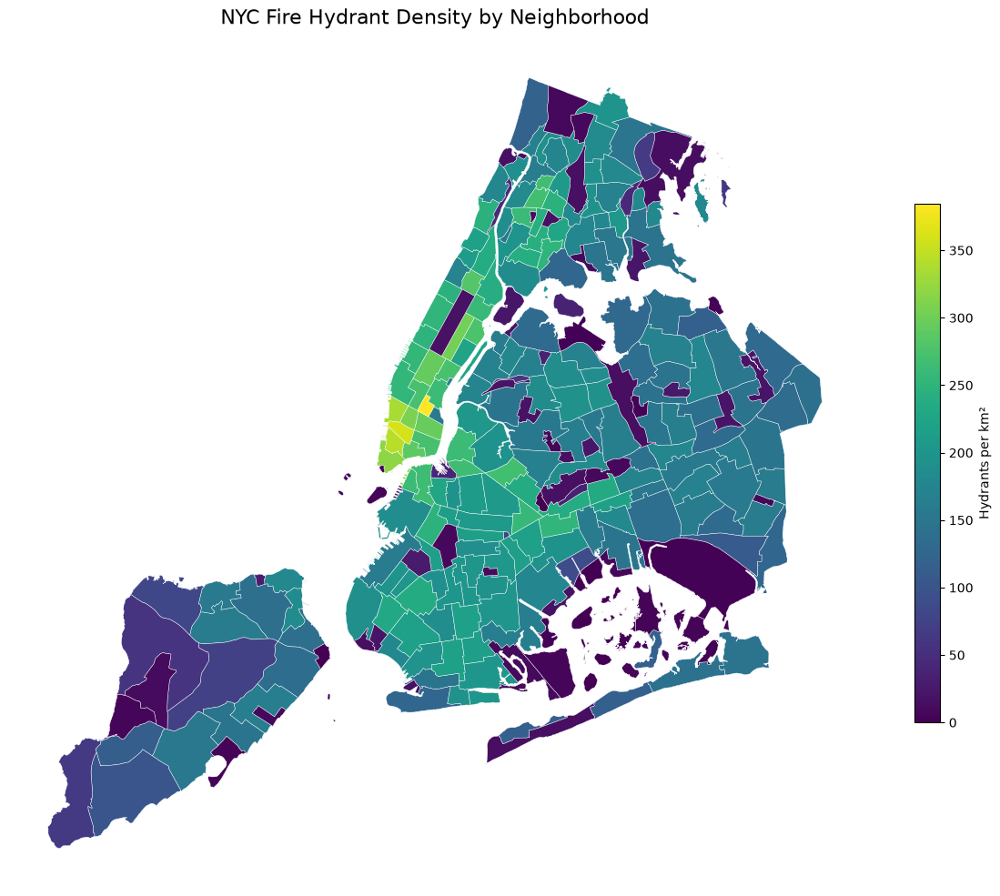

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
result.to_crs(3857).plot(
    column="density_per_km2",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax,
    legend_kwds={"label": "Hydrants per km²", "shrink": 0.6},
)
ax.set_title("NYC Fire Hydrant Density by Neighborhood", fontsize=16, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("images/density_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

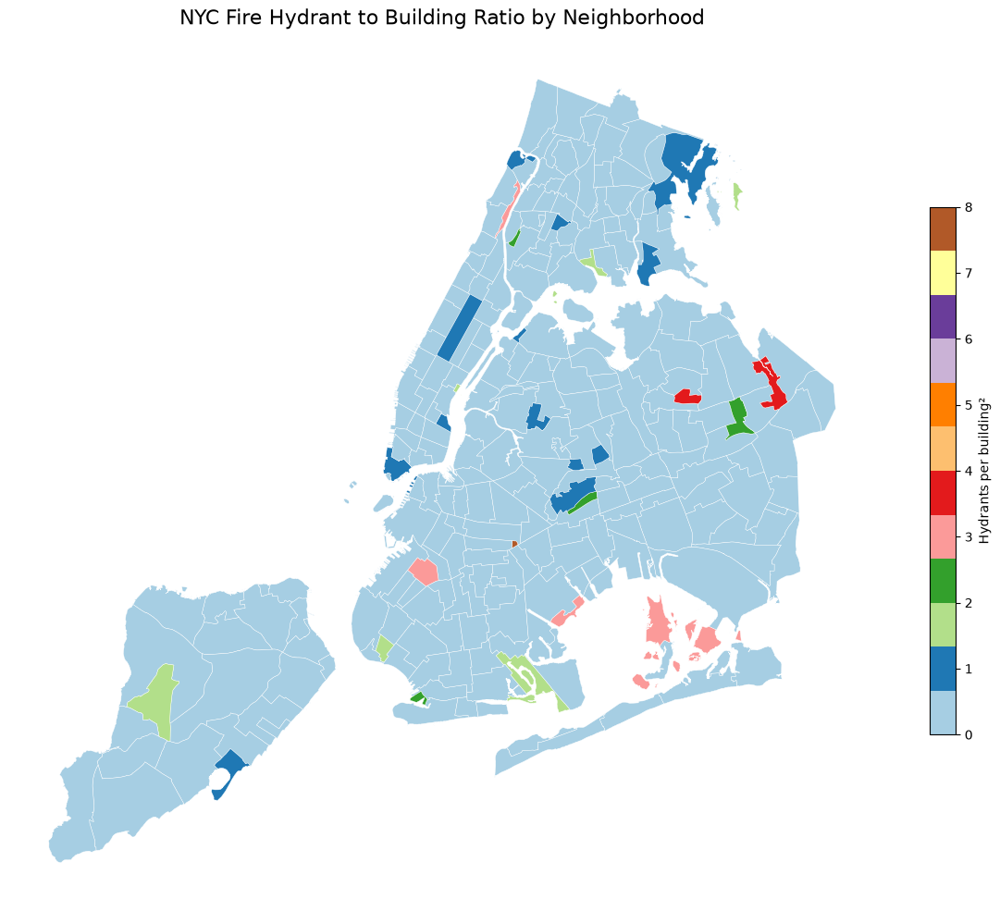

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
final_results.to_crs(3857).plot(
    column="hydrants_per_building",
    cmap="Paired",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax,
    legend_kwds={"label": "Hydrants per building²", "shrink": 0.6},
)
ax.set_title("NYC Fire Hydrant to Building Ratio by Neighborhood", fontsize=16, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("images/density_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

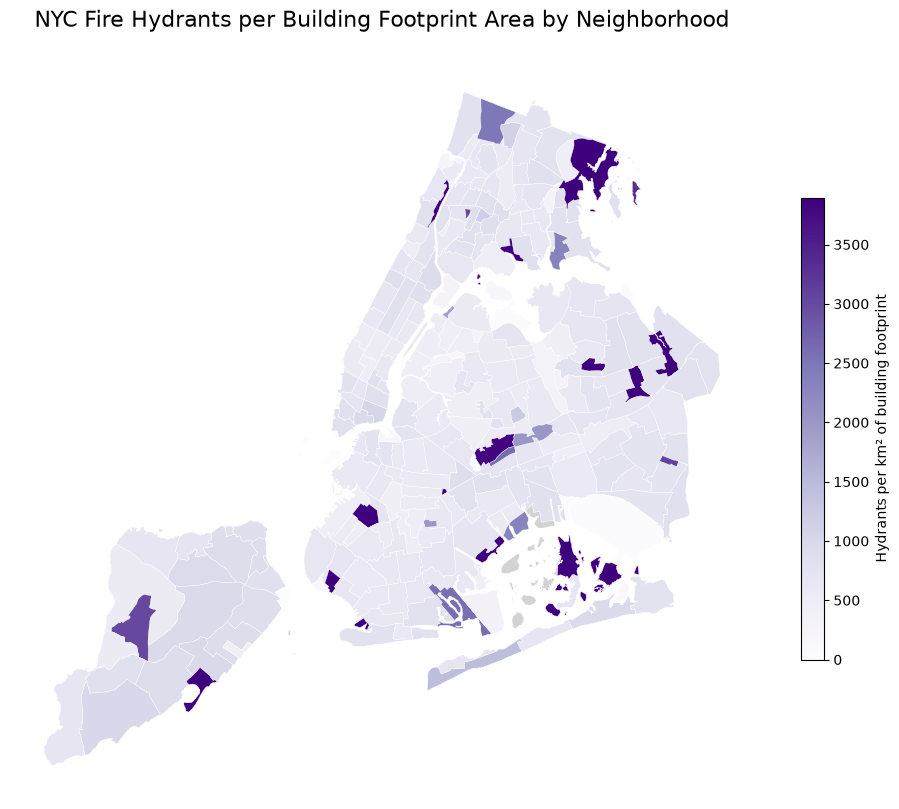

In [ ]:
import numpy as np

col = "hydrants_per_building_km2"
final_results[col] = final_results[col].replace([np.inf, -np.inf], np.nan)

plot_data = final_results.to_crs(3857)

finite = plot_data[col].dropna()

fig, ax = plt.subplots(figsize=(12, 10))
plot_data.plot(
    column=col,
    cmap="Purples",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax,
    vmin=finite.min(),
    vmax=finite.quantile(0.95),
    missing_kwds={"color": "lightgrey", "label": "No buildings"},
    legend_kwds={"label": "Hydrants per km² of building footprint", "shrink": 0.6},
)
ax.set_title("NYC Fire Hydrants per Building Footprint Area by Neighborhood", fontsize=16, pad=12)
ax.set_axis_off()
plt.savefig("images/density_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
col = final_results["hydrants_per_building_km2"]
print("inf count:   ", np.isinf(col).sum())
print("NaN count:   ", col.isna().sum())
print("finite count:", np.isfinite(col).sum())
print(col[np.isfinite(col)].describe())

inf count:    1
NaN count:    2
finite count: 259
count      259.000000
mean      1597.522320
std       6448.471050
min          0.000000
25%        586.510040
50%        699.386652
75%        809.797087
max      96613.436219
Name: hydrants_per_building_km2, dtype: float64


## Visualize: interactive map

For a richer README, take a screenshot of this map after running.

In [ ]:
result[["ntaname", "boroname", "hydrant_count", "density_per_km2", "geometry"]].explore(
    column="density_per_km2",
    cmap="viridis",
    tooltip=["ntaname", "boroname", "hydrant_count", "density_per_km2"],
    legend=True,
    style_kwds={"weight": 0.5, "color": "white", "fillOpacity": 0.7},
)

In [ ]:
final_results[["ntaname", "boroname", "hydrant_count", "building_count", "hydrants_per_building", "building_area_km2", "hydrants_per_building_km2", "geometry"]].explore(
    column="hydrants_per_building",
    cmap="Paired",
    tooltip=["ntaname", "boroname", "hydrant_count", "building_count", "hydrants_per_building", "building_area_km2", "hydrants_per_building_km2"],
    legend=True,
    style_kwds={"weight": 0.5, "color": "white", "fillOpacity": 0.7},
)

In [ ]:
import numpy as np

col = "hydrants_per_building_km2"

# 1. Replace inf with NaN in every ratio column you're mapping
for c in ["hydrants_per_building", "hydrants_per_building_km2"]:
    final_results[c] = final_results[c].replace([np.inf, -np.inf], np.nan)

# 2. Select columns for the map
cols = [
    "ntaname", "boroname", "hydrant_count", "building_count",
    "hydrants_per_building", "building_area_km2", col, "geometry",
]
map_data = final_results[cols].copy()

# 3. Round numbers so the tooltips are readable
map_data = map_data.round({
    "hydrants_per_building": 2,
    "building_area_km2": 3,
    col: 1,
})

# 4. Explore with a capped color scale
map_data.explore(
    column=col,
    cmap="Purples",
    tooltip=[c for c in cols if c != "geometry"],
    legend=True,
    vmin=map_data[col].min(),
    vmax=map_data[col].quantile(0.95),  # stops outliers washing out the colors
    missing_kwds={"color": "lightgrey", "label": "No buildings"},
    style_kwds={"weight": 0.5, "color": "white", "fillOpacity": 0.7},
)

## Export to GeoParquet

This is the artifact PP3 (web map) will reuse. Land it cleanly so the next project can read it without conversion.

In [ ]:
# Keep only the columns that matter downstream.
out = result[[
    "ntaname", "boroname", "hydrant_count", "area_km2", "density_per_km2", "geometry"
]].copy()
out.to_parquet("data/processed/hydrant_density.parquet")
print("Wrote data/processed/hydrant_density.parquet")
print("Shape:", out.shape)
print("CRS:  ", out.crs)

Wrote data/processed/hydrant_density.parquet
Shape: (262, 6)
CRS:   EPSG:2263


In [ ]:
# Keep only the columns that matter downstream.
out = final_results[[
    "ntaname", "boroname", "hydrant_count", "building_count", "hydrants_per_building", "building_area_km2", "hydrants_per_building_km2", "geometry"
]].copy()
out.to_parquet("data/processed/hydrant_density_buidlings.parquet")
print("Wrote data/processed/hydrant_density_buildings.parquet")
print("Shape:", out.shape)
print("CRS:  ", out.crs)

Wrote data/processed/hydrant_density_buildings.parquet
Shape: (262, 8)
CRS:   EPSG:2263


## What I learned

Starting this project in SQL was a goof first step I was able to focus on building concise queries that would get me the data I needed quickly. Moving that into Python is what allowed me to build upon those initial 5 queries. Seeing how the data was normalized in the first map is what made me question using the area of each neighborhood. Without any indicator of how developed a neighborhood is, its difficult to truly understand how the number of hydrants compares from one neighbhoord to another. 

If neighbhorhood X is 10 times larger in size than neighbhorhood Y, but they both have a smilar amount of total building footprint area, it would stand to reason we don't need 10x more hydrants in neighboord xX When dealing with city fires, total size of neighborhood matters, of course, but so does the amount of development. Using building count and building area serves as an indiciator that there are more people as well, which can help further clarify where hydrants are needed. 

With this normaliztion executed, the map actually shows a much smaller graident. Most neighbhoords contain a similar ratio of hydrants to building area and building count, wheras the initial building per neighbhoord area might lead someone to believe theres a great disparity from one neigbhorhood/borough to the next. 

The only areas that pop out using the building methodology are parks, where theres so little building/building area that ratios are incredibly high (even when there aren't necessarily a lot of hydrants). 

The challenge here wasn't about data wrangling or exeucting analysis, it was figuring out how best to answe the guiding question: Where is hydrant coverage densest in NYC, and which neighborhoods are underserved relative to their area? And to me, while density can include hydrants per sheet acreage, it should also include hydrants per buildings. 

---

*Companion to:* `analysis.sql` (same analysis in PostGIS), and the case-study README.